# tACS Bandit: Main Analyses

**Study:** Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan

**Design:** Within-subject crossover (active vs. sham theta-tACS, 6 Hz)

This notebook orchestrates all pre-registered and exploratory analyses by calling modular functions. Individual modules contain the implementation details.

---
## 0. Setup & Imports

In [3]:
# Standard
import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Visualization
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = 'plotly_white'

# Project modules
from config import *
from data_loading import load_all_subjects, summarize_loading
from exclusions import apply_all_exclusions
from sample_descriptives import run_sample_descriptives
from blinding_analysis import run_blinding_analysis
from wsls import run_wsls_analysis
from reversal_analysis import run_reversal_analysis
from rescorla_wagner import run_rw_analysis
from ddm import run_ddm_analysis
from eeg_theta import run_theta_analysis
from cognitive_merge import run_cognitive_merge
from hypothesis_tests import run_hypothesis_tests
from order_effects import run_order_effects_analysis
from correlations import run_correlation_analysis

print(f'Study: {len(SUBJECT_INFO)} participants in SUBJECT_INFO')
print(f'Data directory: {DATA_DIR}')

Study: 32 participants in SUBJECT_INFO
Data directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/bandit


---
## 1. Data Loading & Preprocessing

In [5]:
# Load all behavioral data
data = load_all_subjects()
summarize_loading(data)

Loading sub-10369...
  Run 1: 67 trials, 4 missed
  Run 2: 68 trials, 2 missed
  Run 3: 74 trials, 0 missed
  Run 4: 77 trials, 0 missed
  Run 5: 79 trials, 0 missed
  Run 6: 76 trials, 1 missed
  Run 7: 76 trials, 0 missed
  Run 8: 77 trials, 0 missed
Loading sub-10418...
  Run 1: 73 trials, 0 missed
  Run 2: 71 trials, 0 missed
  Run 3: 73 trials, 0 missed
  Run 4: 73 trials, 0 missed
  Run 5: 74 trials, 0 missed
  Run 6: 73 trials, 0 missed
  Run 7: 70 trials, 1 missed
  Run 8: 69 trials, 0 missed
Loading sub-10541...
  Run 1: 70 trials, 2 missed
  Run 2: 69 trials, 1 missed
  Run 3: 70 trials, 4 missed
  Run 4: 71 trials, 5 missed
  Run 5: 72 trials, 0 missed
  Run 6: 72 trials, 2 missed
  Run 7: 73 trials, 1 missed
  Run 8: 71 trials, 2 missed
Loading sub-10559...
  Run 1: 72 trials, 2 missed
  Run 2: 72 trials, 4 missed
  Run 3: 76 trials, 1 missed
  Run 4: 77 trials, 0 missed
  Run 5: 77 trials, 0 missed
  Run 6: 75 trials, 1 missed
  Run 7: 74 trials, 2 missed
  Run 8: 73 trial

,subject_id,n_runs,n_trials,n_missed,pct_missed,counterbalance,conditions
0,10369,8,594,7,1.178451,B,"[active, baseline, post, sham]"
1,10418,8,576,1,0.173611,B,"[active, baseline, post, sham]"
2,10541,8,568,17,2.992958,B,"[active, baseline, post, sham]"
3,10559,8,596,13,2.181208,A,"[active, baseline, post, sham]"
4,10589,8,597,3,0.502513,A,"[active, baseline, post, sham]"
5,10606,8,598,2,0.334448,A,"[active, baseline, post, sham]"
6,10608,8,586,3,0.511945,A,"[active, baseline, post, sham]"
7,10636,8,611,3,0.490998,B,"[active, baseline, post, sham]"
8,10638,8,578,10,1.730104,B,"[active, baseline, post, sham]"
9,10641,8,593,3,0.505902,B,"[active, baseline, post, sham]"


In [6]:
# Apply exclusion criteria
exclusion_results = apply_all_exclusions(data)

# Extract filtered datasets
data_h1 = exclusion_results['data_h1']       # H1 analyses: sham only, behavioral exclusions
data_h2 = exclusion_results['data_h2']       # H2 analyses: active vs sham, all exclusions
data_clean = exclusion_results['data_clean'] # All clean trials
run_exclusions = exclusion_results['run_exclusions']
h2_eligible = exclusion_results['h2_eligible']

print(f'\nH1-eligible subjects: {data_h1["subject_id"].nunique()}')
print(f'H2-eligible subjects: {len(h2_eligible)}')

Computing Pre-Registered Exclusion Criteria

Behavioral Exclusion Summary (Run-Level):
--------------------------------------------------
  ⚠ >20% missed trials: 1/248 runs (0%)
  ⚠ Side bias (>95%): 3/248 runs (1%)
  ⚠ Stimulus bias (>95%): 6/248 runs (2%)
  ⚠ Rapid responding (<200ms): 1/248 runs (0%)
  ⚠ Feedback invariance (10+ losses): 2/248 runs (1%)

Stimulation Administration Exclusions: 3 runs
  sub-10998 Run 6: Experimenter error: sham protocol loaded instead of active
  sub-11773 Run 6: Experimenter error: sham protocol loaded instead of active
  sub-11773 Run 7: Experimenter error: sham protocol loaded instead of active

Combined Exclusion Summary

Total subjects: 31
Total runs: 248
Runs excluded (behavioral): 12
Runs excluded (stim admin): 3
Unique runs excluded for H2: 14

H1 sample (sham, behavioral exclusions):
  31 subjects, 61 clean sham runs, 4509 trials

H2 sample (active vs. sham, all exclusions + min-run threshold):
  29 subjects eligible for paired comparisons, 8

---
## 2. Sample Descriptives & Demographics

Sample Descriptives

N = 32
Age: M = 45.5, SD = 19.8, range = 23–75

Gender:
  Female: 17 (53%)
  Male: 15 (47%)

Race:
  White: 24 (75%)
  Black or African American: 4 (12%)
  Asian: 3 (9%)
  Two or more races, or race not described (other): 1 (3%)

Ethnicity:
  Not Hispanic or Latino: 28 (88%)
  Hispanic or Latino: 3 (9%)
  Ethnicity not described (Other): 1 (3%)



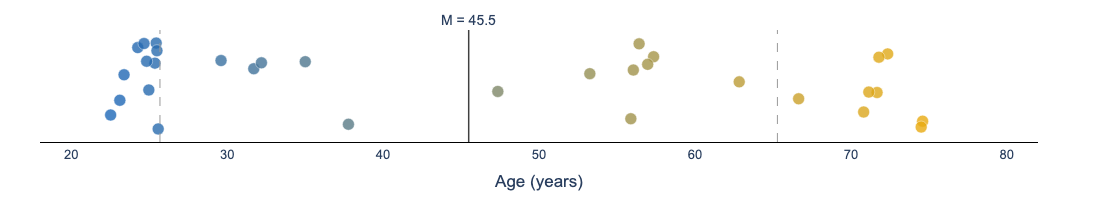


Estimated vs Actual Cap Size Comparison

Subjects with ICV data: 32
Subjects with both estimated and actual: 25
  Matches (same size): 15
  Off by 1 size: 9
  Off by 2 sizes: 1

Mismatch direction:
  Actual smaller than estimated: 9
  Actual larger than estimated: 1

 Subject      ICV      Estimated       Actual       Status
------------------------------------------------------------
   10369   1534.5          Large        Large      ✓ Match
   10418   1329.0              —       Medium   Incomplete
   10541   1614.6    Extra Large        Large    ✗ +1 size
   10559   1443.6          Large        Large      ✓ Match
   10589   1494.2          Large            —   Incomplete
   10606   1489.6          Large        Large      ✓ Match
   10608   1197.5          Small        Small      ✓ Match
   10636   1313.4              —        Small   Incomplete
   10638   1235.7          Small        Small      ✓ Match
   10641   1313.5          Small        Small      ✓ Match
   10649   1395.5    

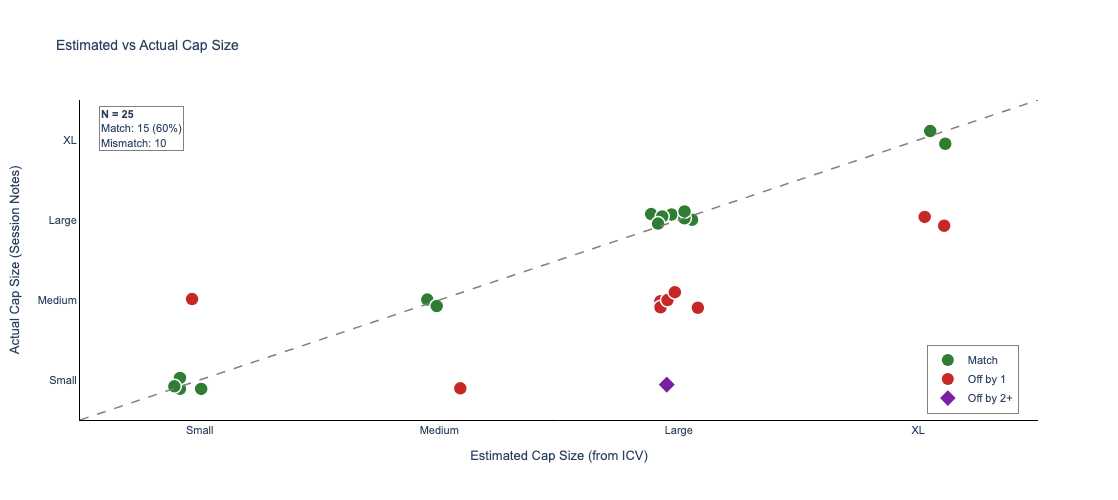

In [8]:
# Demographics and cap size analysis
desc_results = run_sample_descriptives()

---
## 3. Blinding Integrity

Blinding Integrity Analysis

Data: 117 run-level observations from 31 participants

--- Contingency Table ---
                 Participant Guess
Actual Condition   Active    Sham    Total
---------------------------------------------
     Active            43       16       59
      Sham             33       25       58
---------------------------------------------
     Total             76       41      117

--- Signal Detection Metrics ---
  Hits (say Active | Active):            43 / 59 = 72.9%
  Misses (say Sham | Active):            16 / 59 = 27.1%
  False Alarms (say Active | Sham):      33 / 58 = 56.9%
  Correct Rejections (say Sham | Sham):  25 / 58 = 43.1%

  d' (sensitivity):  +0.43  (near zero — no discrimination)
  c (criterion):     -0.38  (bias toward "Active")

  Overall accuracy: 58.1% (68/117)
  Binomial vs 50%: p = 0.096
  χ² = 2.62, p = 0.106

--- By Counterbalance Order ---
Order    N_runs        Hits          FA       d'      Acc
-----------------------------------

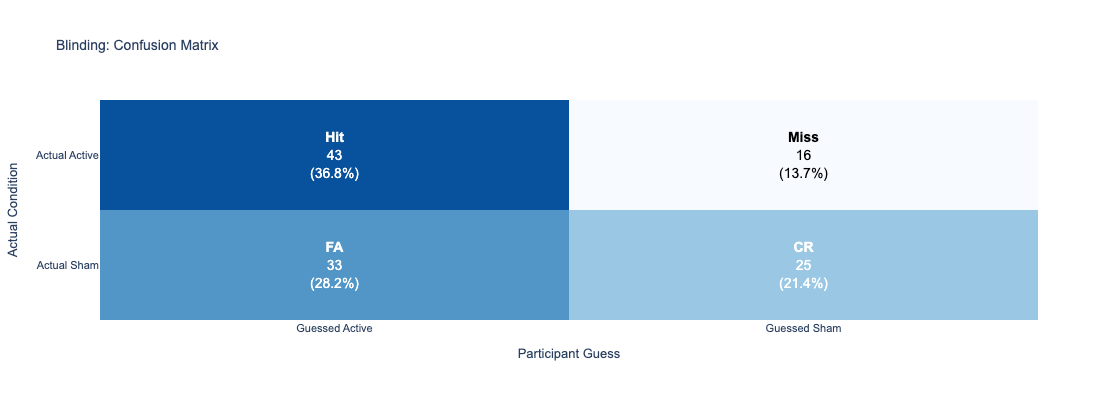

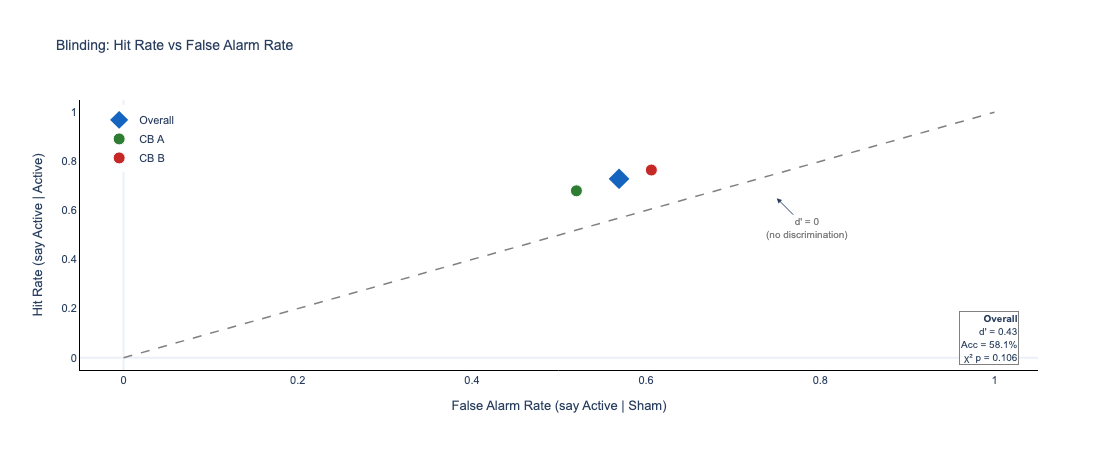


✓ Blinding appears intact


In [10]:
# Signal detection analysis of blinding
blinding_results = run_blinding_analysis(data_clean)

if blinding_results['blinding_intact']:
    print('\n✓ Blinding appears intact')
else:
    print('\n⚠ Blinding may be compromised — interpret with caution')

---
## 4. Win-Stay / Lose-Shift Analysis

H1 WSLS (sham, clean runs):
subject_id  p_stay_win  p_shift_lose  n_win_trials  n_lose_trials  n_total_trials
     10369    0.591549      0.507692            71             65             136
     10418    0.959459      0.500000            74             68             142
     10541    0.945946      0.648148            74             54             128
     10559    0.881579      0.353846            76             65             141
     10589    0.913462      0.369565           104             46             150
     10606    0.439024      0.470588            41             34              75
     10608    0.976744      0.677966            86             59             145
     10636    0.989796      0.395833            98             48             146
     10638    0.459459      0.420290            74             69             143
     10641    0.873418      0.606557            79             61             140
     10649    0.987952      0.508475            83             59     

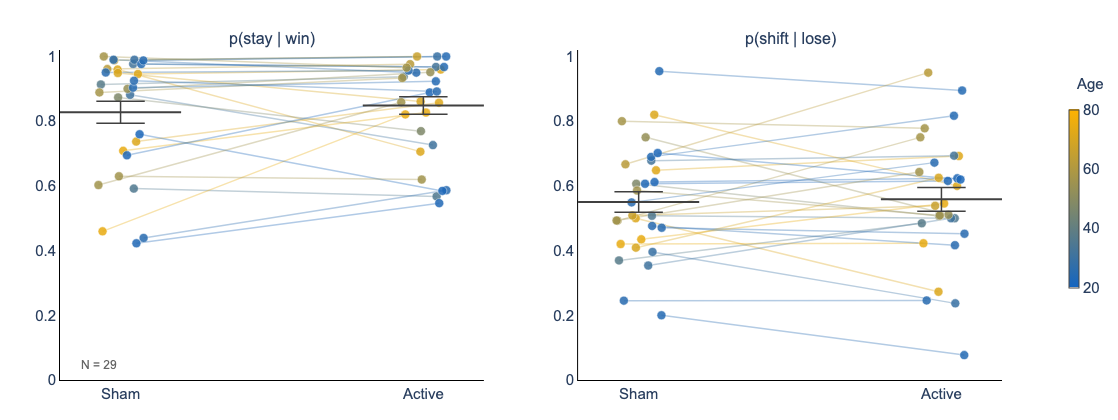

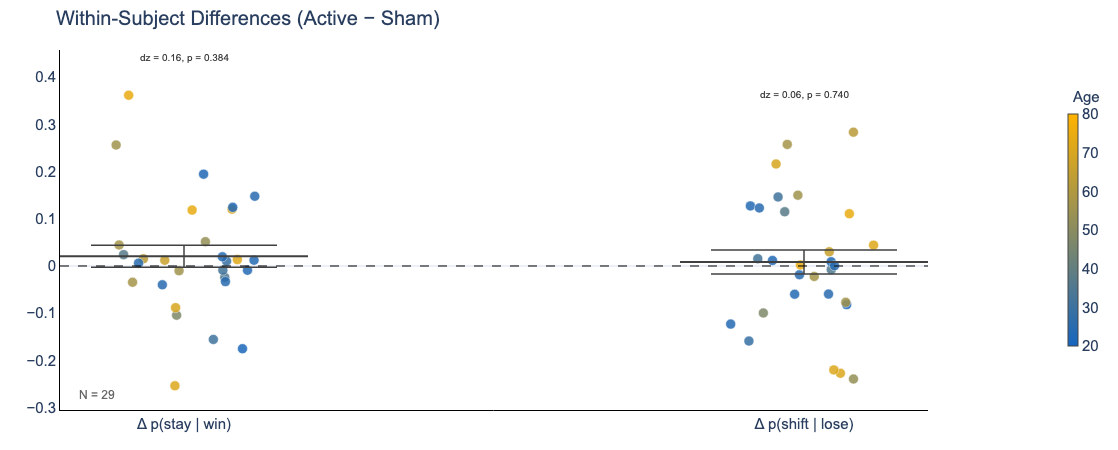

In [12]:
# WSLS analysis for H1 and H2
wsls_results = run_wsls_analysis(data_h1, data_h2, data)

---
## 5. Reversal Learning Analysis

Identified 498 reversals across 31 subjects
Trials in reversal windows: 10363 / 18347

Reversals per subject × condition:
condition   active  baseline  post  sham
subject_id                              
10369            4         4     4     4
10418            4         4     4     4
10541            4         4     4     4
10559            4         4     4     4
10589            4         4     4     4
10606            4         4     4     4
10608            4         4     4     4
10636            4         4     4     4
10638            4         4     4     4
10641            4         4     4     4
10649            4         4     4     4
10656            4         4     4     4
10661            4         4     4     4
10716            4         4     5     4
10809            4         4     4     4
10810            4         4     4     4
10862            4         4     4     4
10866            4         4     4     4
10886            4         4     4     4
10951            

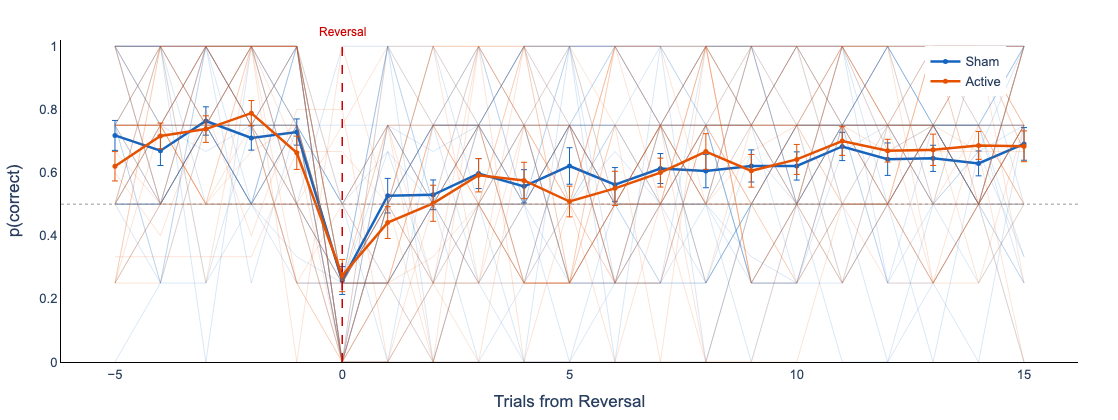

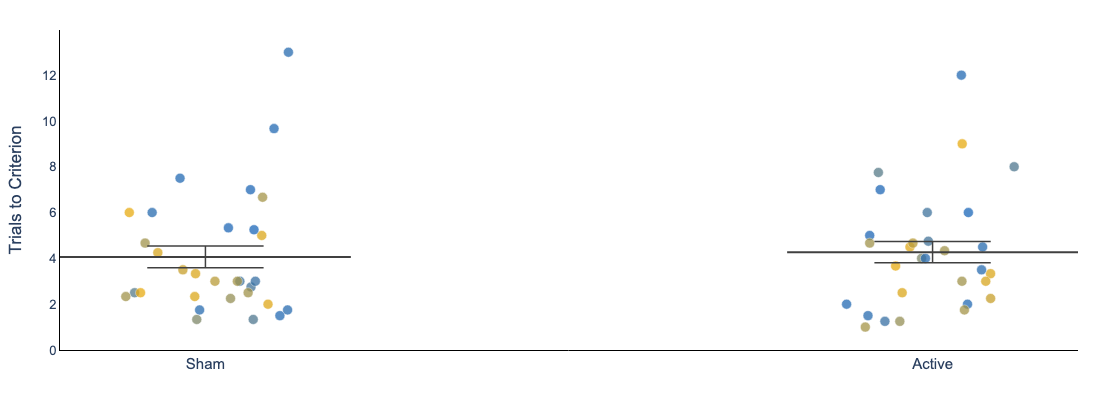

In [14]:
# Reversal-locked accuracy and trials to criterion
rev_results = run_reversal_analysis(data, data_clean, conditions=['sham', 'active'])

---
## 6. Rescorla-Wagner Model

In [16]:
# Fit R-W model (MLE and MAP)
rw_results = run_rw_analysis(
    data_clean, 
    h2_subjects=h2_eligible,
    run_recovery=False  # Set True to run parameter recovery (slow)
)


Rescorla-Wagner Model Fitting

Fitted 61 subject × condition blocks

⚠ WARNING: 21 fits hit parameter boundaries

MLE vs MAP correlation: α = 0.942, β = 0.640

Subject-level fits: 31 subjects
  α: M = 0.654, SD = 0.382
  β: M = 4.20, SD = 7.73

--------------------------------------------------
Paired Comparison (H2 subjects)
--------------------------------------------------
  alpha: Δ = +0.049, dz = 0.15, t(28) = 0.80, p = 0.4332
  beta: Δ = -0.026, dz = -0.00, t(28) = -0.02, p = 0.9859


---
## 7. Drift Diffusion Model

In [19]:
# Fit DDM (requires pyddm)
ddm_results = run_ddm_analysis(
    data_clean,
    conditions=['sham', 'active'],
    run_bootstrap=False,  # Set True for bootstrap CI (slow)
    n_bootstrap=200
)

Drift Diffusion Model Analysis

DDM data preparation:
  Retained: 17058 trials (97.4%)
  Excluded: 452 trials
  Participants: 31
  Conditions: ['baseline', 'sham', 'active']

RT distribution (seconds):
  Mean: 0.623, Median: 0.540
  SD: 0.299

Overall accuracy: 64.7%

--------------------------------------------------
Condition-Level DDM Fits
--------------------------------------------------
  Fitting sham condition (n=4210 trials)...


Info: Params [0.28783077 0.76890098 0.21719604] gave 31735.683173508354


    v = 0.288, a = 0.769, t = 0.217s
  Fitting active condition (n=4267 trials)...


Info: Params [0.30796952 0.77930212 0.19815914] gave 33524.53771353409
Info: Params [0.39710003 0.88950561 0.14542992] gave 1348.7907104779943


    v = 0.308, a = 0.779, t = 0.198s

--------------------------------------------------
Condition Comparison
--------------------------------------------------
  v: sham = 0.288, active = 0.308, Δ = +0.020
  a: sham = 0.769, active = 0.779, Δ = +0.010
  t: sham = 0.217, active = 0.198, Δ = -0.019

--------------------------------------------------
Subject-Level DDM Fits
--------------------------------------------------


...

  Processing subject 25/31


Info: Params [0.36994749 0.71444695 0.2829291 ] gave 1140.019096110992
Info: Params [0.41313953 0.72743393 0.27984712] gave 1190.5173581715992
Info: Params [0.35712994 0.73831029 0.23001234] gave 604.8176978045116
Info: Params [0.19316996 0.63946397 0.25684122] gave 848.6421372355675
Info: Params [0.13396863 0.66222847 0.22662026] gave 790.1777442022376
Info: Params [0.30451551 0.71339797 0.21693238] gave 1118.6039703758438
Info: Params [0.55421831 0.67005828 0.1979425 ] gave 1349.3086200513494
Info: Params [0.43123126 0.6885468  0.2400297 ] gave 1214.1392577557606
Info: Params [0.28827648 0.65514517 0.3342933 ] gave 963.7642036146083
Info: Params [0.26175946 0.69650047 0.37723801] gave 946.6252693623425


  Processing subject 30/31


Info: Params [0.28761836 0.75243384 0.31097992] gave 1067.6472898210568
Info: Params [0.38494584 0.7826727  0.14201101] gave 1184.8330176296517
Info: Params [0.44605339 0.65296338 0.14097181] gave 381.00850861604863



  Complete cases (both conditions): 30

  V: Δ = +0.028, dz = 0.23, t = 1.24, p = 0.226

  A: Δ = -0.006, dz = -0.11, t = -0.58, p = 0.567

  T: Δ = -0.008, dz = -0.16, t = -0.89, p = 0.380


---
## 8. EEG Theta Reactivity

Theta Reactivity Analysis (Baseline Runs)

Computing theta reactivity...
  Sub-10998 Run 5: θ_p95 = 209.4%
  Sub-11773 Run 1: θ_p95 = 362.7%
  Sub-11773 Run 5: θ_p95 = 327.2%
  Sub-10886 Run 1: θ_p95 = 201.1%
  Sub-10886 Run 5: θ_p95 = 197.0%
  Sub-10656 Run 1: θ_p95 = 207.5%
  Sub-10656 Run 5: θ_p95 = 210.7%
  Sub-10951 Run 1: θ_p95 = -90.5%
  Sub-10951 Run 5: θ_p95 = 263.8%
  Sub-10418 Run 1: θ_p95 = 205.9%
  Sub-10418 Run 5: θ_p95 = 215.2%
  Sub-10636 Run 1: θ_p95 = 143.0%
  Sub-10636 Run 5: θ_p95 = 274.4%
  Sub-11318 Run 1: θ_p95 = 283.1%
  Sub-11318 Run 5: θ_p95 = 292.8%
  Sub-10369 Run 1: θ_p95 = 301.5%
  Sub-10369 Run 5: θ_p95 = 243.2%
  Sub-10606 Run 1: θ_p95 = 244.8%
  Sub-10606 Run 5: θ_p95 = 127.9%
  Sub-11628 Run 1: θ_p95 = 218.4%
  Sub-11628 Run 5: θ_p95 = 234.2%
  Sub-11286 Run 1: θ_p95 = 221.2%
  Sub-11286 Run 5: θ_p95 = 224.4%
  Sub-10866 Run 1: θ_p95 = 229.6%
  Sub-10866 Run 5: θ_p95 = 209.6%
  Sub-11329 Run 1: θ_p95 = 282.7%
  Sub-11329 Run 5: θ_p95 = 255.1%
  Sub-106

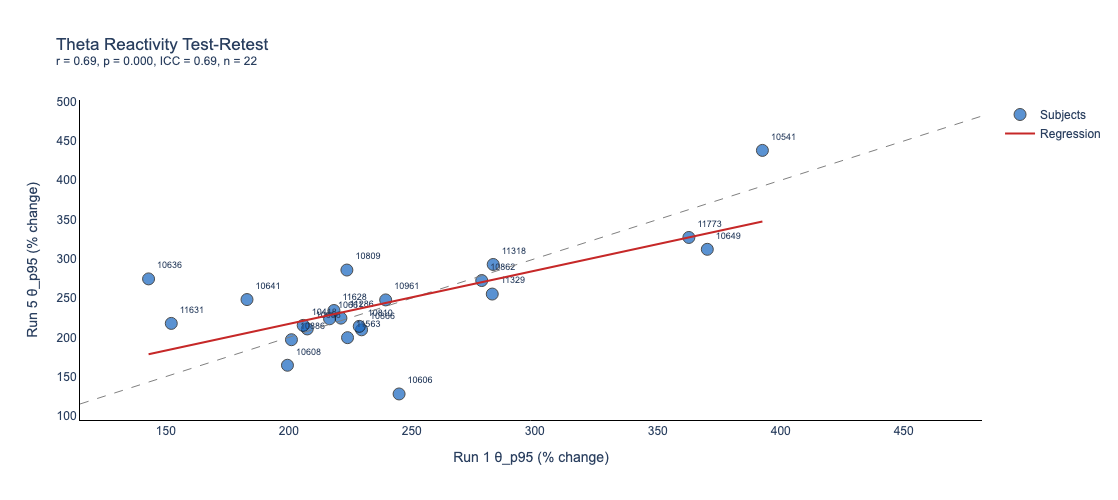

Insufficient data for age plot

Theta reliability (ICC): 0.691


In [22]:
# Compute theta reactivity from baseline EEG (F4 channel)
# Note: Requires EEG .easy files in DATA_DIR/nic/raw
try:
    theta_results = run_theta_analysis(verbose=True, show_plots=True)
    theta_subject = theta_results.get('theta_subject')
    print(f'\nTheta reliability (ICC): {theta_results["reliability"]["ICC"]:.3f}')
except FileNotFoundError:
    print('EEG files not found - skipping theta analysis')
    theta_results = None
    theta_subject = None

---
## 9. Cognitive & Survey Data Integration

In [26]:
# Load external data and build subject DataFrame
cog_results = run_cognitive_merge(
    wsls_h1=wsls_results.get('wsls_h1'),
    wsls_h2=wsls_results.get('wsls_h2'),
    rw_mle=rw_results.get('rw_mle'),
    ddm_params=ddm_results.get('ddm_subject') if ddm_results else None,
    theta_subject=theta_subject,
    h2_subjects=h2_eligible
)

subj_df = cog_results['subj_df']
print(f'\nSubject DataFrame: {len(subj_df)} subjects, {len(subj_df.columns)} variables')
if 'theta_p95' in subj_df.columns:
    print(f'Subjects with theta data: {subj_df["theta_p95"].notna().sum()}')

Loading External Data Sources
  RF1 FullScoring: 32 subjects
  RF1 Raw: 32 subjects
  TabCAT: 31 subjects
  tACS REDCap: 32 subjects

--------------------------------------------------
Computing Cognitive Composites
--------------------------------------------------
  attention_composite: 31/32 with data
  memory_composite: 32/32 with data
  speed_composite: 32/32 with data
  global_composite: 32/32 with data
  ef_composite: 31/32 with data

--------------------------------------------------
Building Subject DataFrame
--------------------------------------------------
  Theta reactivity: 28
Subject DataFrame assembled: 32 subjects, 38 variables
  Cognitive composites: 32
  WSLS (sham): 31
  R-W (sham): 31

Subject DataFrame: 32 subjects, 38 variables
Subjects with theta data: 28


---
## 9b. Extended Computational Models (Exploratory)

This section implements more sophisticated RL models to test hypotheses about **confirmation bias**, **perseveration**, and **value differentiation** in aging and tACS effects.

### Models
1. **Asymmetric R-W** (α⁺, α⁻, β): Separate learning rates for positive vs. negative prediction errors
2. **Asymmetric R-W + Stickiness** (α⁺, α⁻, β, τ): Adds perseveration independent of learned values
3. **Standard R-W + Stickiness** (α, β, τ): For model comparison

### Key Parameters
| Parameter | Interpretation |
|-----------|---------------|
| α⁺ | Learning rate for positive prediction errors (confirmatory feedback) |
| α⁻ | Learning rate for negative prediction errors (disconfirmatory feedback) |
| α⁺/α⁻ | Confirmation bias index (>1 = learns more from rewards than losses) |
| τ | Choice stickiness (>0 = perseveration, tendency to repeat regardless of value) |
| β | Inverse temperature / value differentiation |

### Hypotheses Tested
- **H-RL1**: Older adults show elevated α⁺/α⁻ ratios (confirmation bias)
- **H-RL2**: α⁺/α⁻ correlates with WSLS patterns (computational ↔ behavioral link)
- **H-RL5**: β declines with age (reduced value differentiation)
- **H-RL7**: Older adults show elevated τ (perseveration)
- **H-RL8**: τ correlates with poorer executive function

*Note: These analyses are exploratory extensions beyond the pre-registered hypotheses.*

In [30]:
# Import extended R-W module
from rescorla_wagner_extended import run_extended_rw_analysis

EXTENDED RESCORLA-WAGNER ANALYSIS

Models: Asymmetric R-W, Asymmetric R-W + Stickiness, Standard R-W + Stickiness
Method: MLE
Conditions: ['sham', 'active']

Fitting extended models...
  Sub-10369 sham: α⁺=0.001, α⁻=0.100, τ=-0.188
  Sub-10369 active: α⁺=0.004, α⁻=0.916, τ=0.142
  Sub-10418 sham: α⁺=0.019, α⁻=0.914, τ=-0.058
  Sub-10418 active: α⁺=0.999, α⁻=0.001, τ=0.974
  Sub-10541 sham: α⁺=0.187, α⁻=0.657, τ=-0.125
  Sub-10541 active: α⁺=0.617, α⁻=0.267, τ=-0.828
  Sub-10559 sham: α⁺=0.456, α⁻=0.080, τ=-0.071
  Sub-10559 active: α⁺=0.019, α⁻=0.999, τ=0.159
  Sub-10589 sham: α⁺=0.449, α⁻=0.336, τ=0.257
  Sub-10589 active: α⁺=0.072, α⁻=0.337, τ=-0.301
  Sub-10606 sham: α⁺=0.001, α⁻=0.009, τ=-0.093
  Sub-10606 active: α⁺=0.124, α⁻=0.001, τ=-0.101
  Sub-10608 sham: α⁺=0.563, α⁻=0.566, τ=-0.549
  Sub-10608 active: α⁺=0.298, α⁻=0.679, τ=0.001
  Sub-10636 sham: α⁺=0.521, α⁻=0.329, τ=-0.867
  Sub-10636 active: α⁺=0.959, α⁻=0.189, τ=-1.112
  Sub-10638 sham: α⁺=0.059, α⁻=0.004, τ=0.063
  Sub-

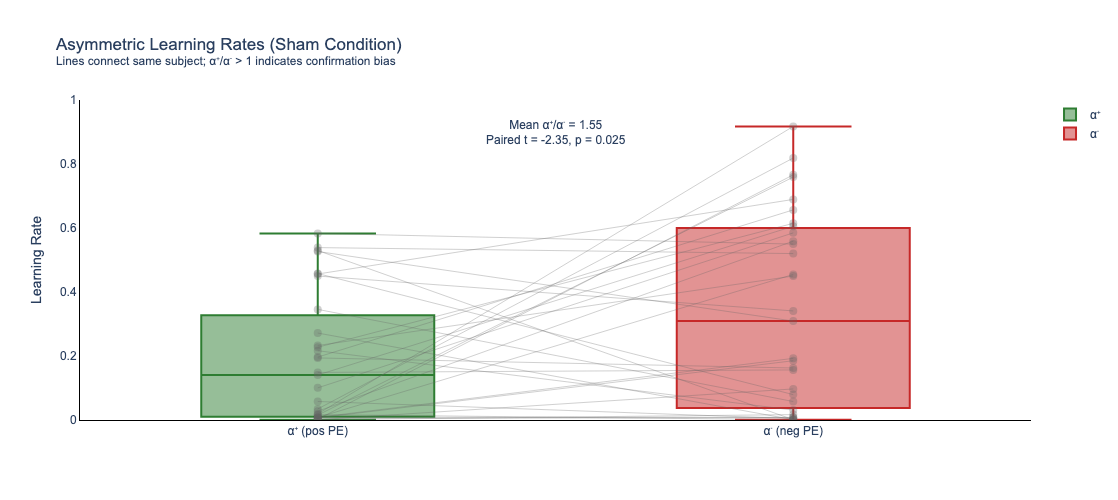

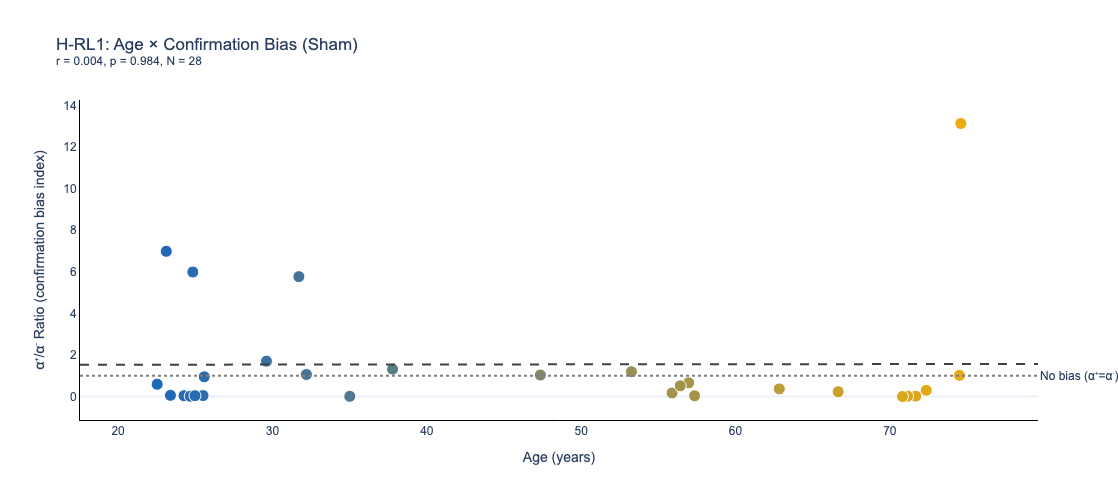

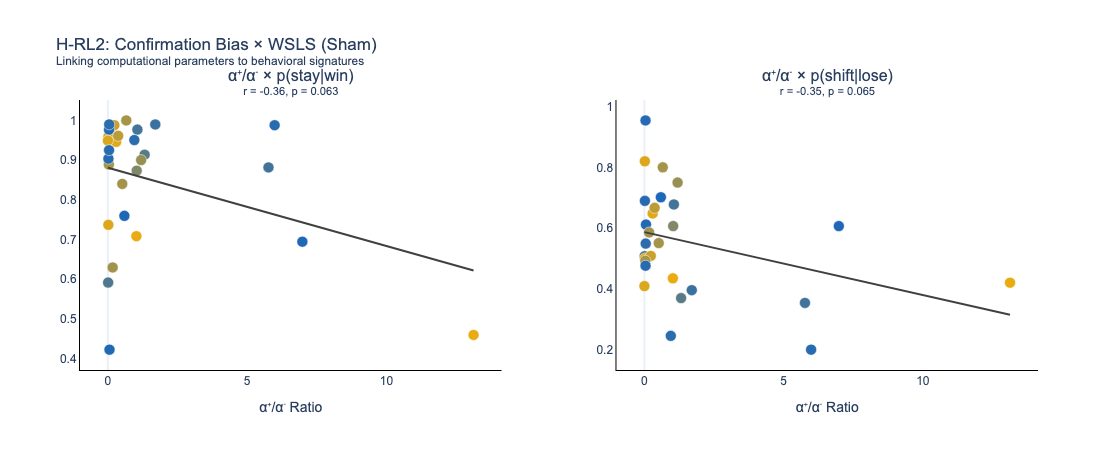

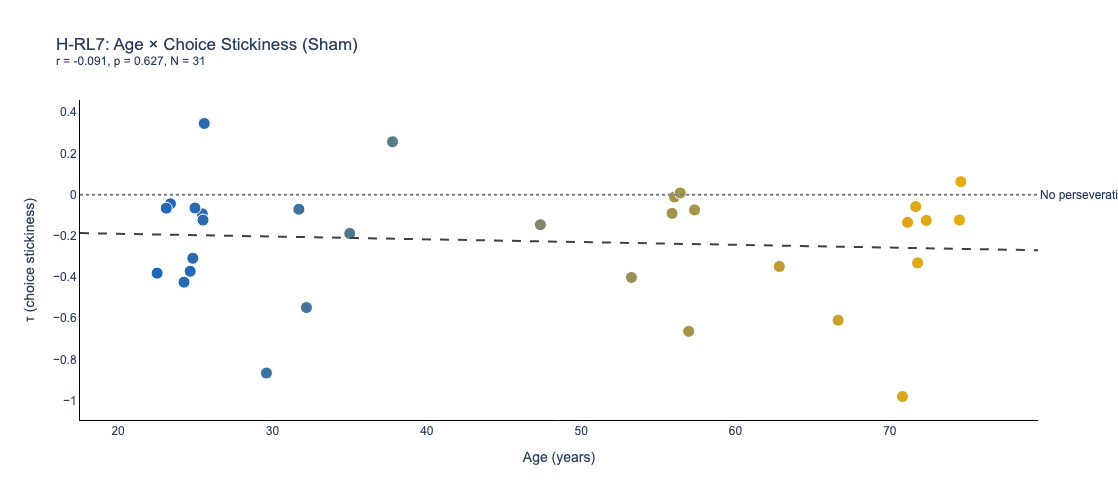

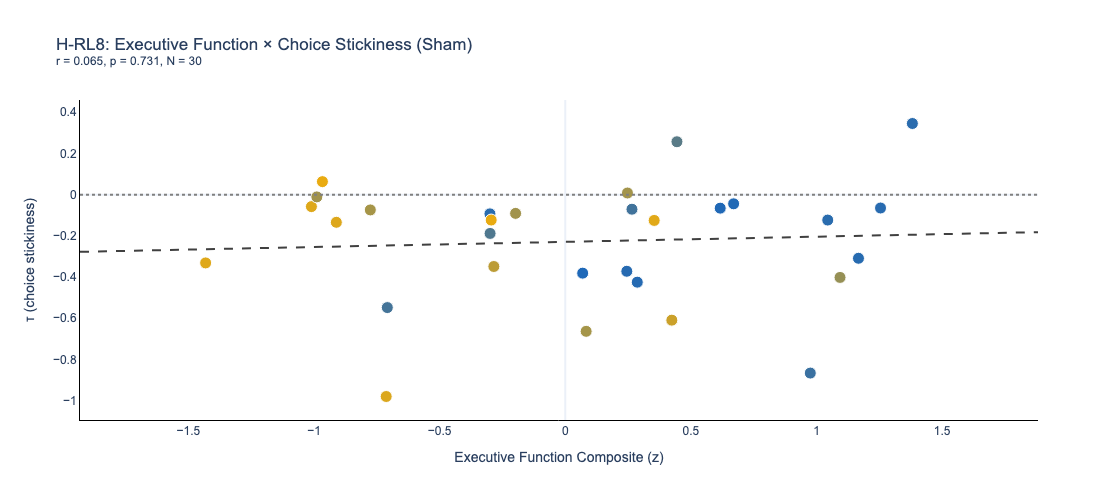

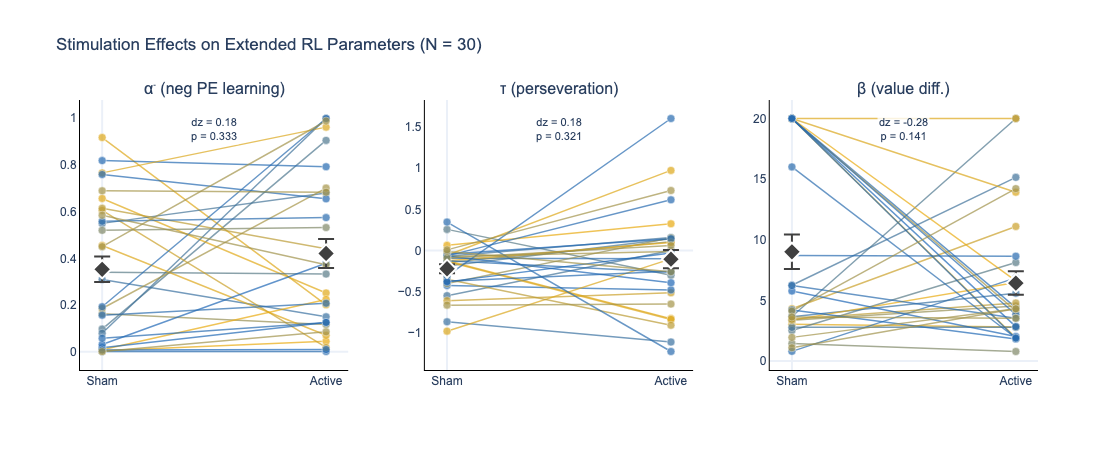

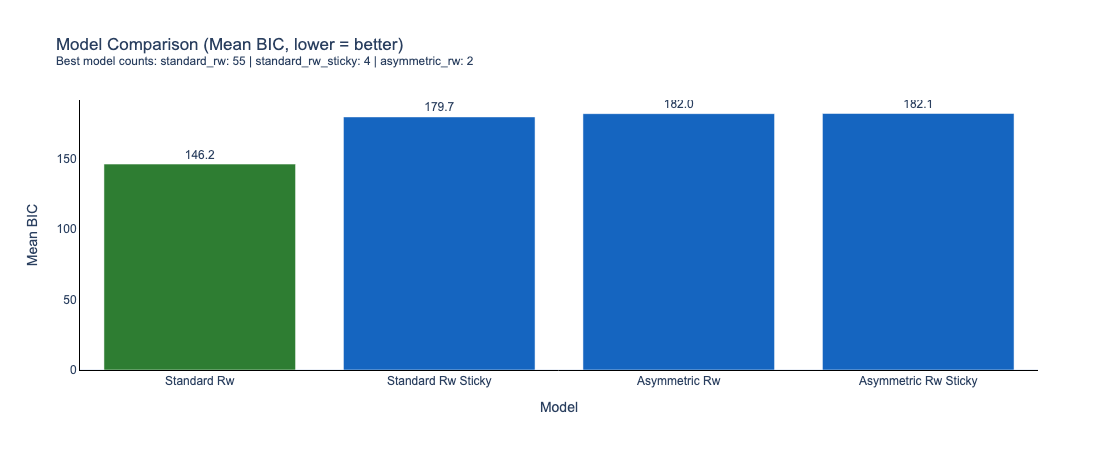

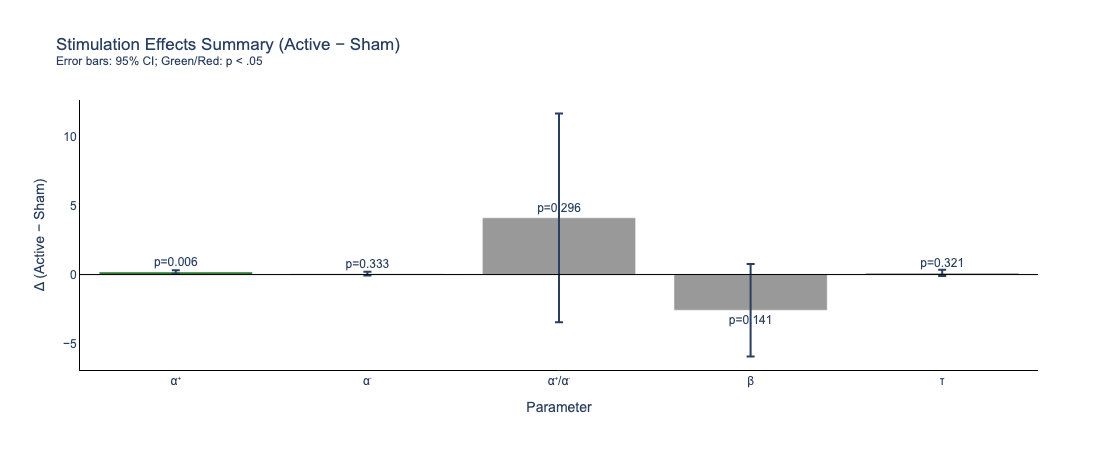




BOUNDARY ESTIMATE DIAGNOSTICS

Total fits: 61

Boundary flags (α < 0.01 or α > 0.99):
  α⁺ at boundary: 13 (21.3%)
  α⁻ at boundary: 10 (16.4%)
  β at boundary: 12 (19.7%)
  |τ| > 2.9: 0 (0.0%)

Extreme α⁺/α⁻ ratio (> 10.0): 3 (4.9%)

Any boundary issue: 24 (39.3%)
Exclude for sensitivity (boundary OR extreme ratio): 25 (41.0%)

Flagged estimates:
subject_id condition  alpha_pos  alpha_neg  alpha_ratio       tau
     10369      sham   0.001000   0.097030     0.010306 -0.188344
     10369    active   0.003298   0.905260     0.003644  0.142445
     10418      sham   0.019093   0.917504     0.020810 -0.058146
     10418    active   0.001000   0.201120     0.004972  0.973523
     10559    active   0.017532   0.999000     0.017550  0.158901
     10606      sham   0.271678   0.001000          NaN -0.093333
     10606    active   0.125849   0.001000          NaN -0.100796
     10638      sham   0.057912   0.004410    13.130463  0.063200
     10649    active   0.304565   0.018224    16.7124

In [31]:
# Run extended R-W analysis
# Uses data_clean for model fitting, subj_df for age/cognitive correlates
# Includes outlier diagnostics and sensitivity analysis

extended_rw_results = run_extended_rw_analysis(
    data=data_clean,
    subj_df=subj_df,
    wsls_df=wsls_results['wsls_h1'],  # For H-RL2: α⁺/α⁻ × WSLS correlations
    standard_rw_df=rw_results['rw_mle'],  # For model comparison with original R-W
    conditions=['sham', 'active'],
    method='mle',
    show_plots=True,
    verbose=True
)

In [33]:
# Extract key results
extended_model_fits = extended_rw_results['model_fits']
extended_comparison = extended_rw_results['comparison']
extended_tests = extended_rw_results['hypothesis_tests']
sensitivity = extended_rw_results['sensitivity']

# Summary: Best model by subject
if 'best_model' in extended_comparison.columns:
    print("\nBest-fitting model distribution:")
    print(extended_comparison['best_model'].value_counts())


Best-fitting model distribution:
best_model
standard_rw           55
standard_rw_sticky     4
asymmetric_rw          2
Name: count, dtype: int64


---
## 10. Pre-Registered Hypothesis Tests

In [ ]:
# Run all H1 and H2 tests
hyp_results = run_hypothesis_tests(subj_df, show_plots=True)

---
## 11. Order & Session Effects

In [42]:
# Check for counterbalance confounds
order_results = run_order_effects_analysis(subj_df)

Sample by Counterbalance Order:
----------------------------------------
  Order A (Active first): n = 13
  Order B (Sham first): n = 19

WSLS/RW Parameters by Order and Condition:
----------------------------------------------------------------------

p(stay|win):
  Order A / Sham  : M = 0.827, SD = 0.220 (n=13)
  Order B / Sham  : M = 0.831, SD = 0.144 (n=18)
  Order A / Active: M = 0.845, SD = 0.167 (n=13)
  Order B / Active: M = 0.851, SD = 0.133 (n=16)

p(shift|lose):
  Order A / Sham  : M = 0.537, SD = 0.198 (n=13)
  Order B / Sham  : M = 0.547, SD = 0.151 (n=18)
  Order A / Active: M = 0.576, SD = 0.196 (n=13)
  Order B / Active: M = 0.544, SD = 0.202 (n=16)

α:
  Order A / Sham  : M = 0.565, SD = 0.459 (n=13)
  Order B / Sham  : M = 0.641, SD = 0.405 (n=18)
  Order A / Active: M = 0.664, SD = 0.374 (n=13)
  Order B / Active: M = 0.666, SD = 0.345 (n=16)

β:
  Order A / Sham  : M = 5.447, SD = 3.895 (n=13)
  Order B / Sham  : M = 5.969, SD = 10.312 (n=18)
  Order A / Active: M =

---
## 12. Correlation Matrix


Variables included: 16 total
  Primary: 12
  Secondary: 4

Pairwise sample sizes (min/max):
  Min N: 14
  Max N: 32
  Median N: 30

Significant correlations (p < .05): 20
  Attention × Exec. Func.: r = 0.932, p = 0.0000
  Global Cog. × Proc. Speed: r = 0.826, p = 0.0000
  Global Cog. × Ep. Memory: r = 0.764, p = 0.0000
  Global Cog. × Attention: r = 0.770, p = 0.0000
  Global Cog. × Exec. Func.: r = 0.708, p = 0.0000
  p(stay|win) × α (learn rate): r = 0.705, p = 0.0000
  SPSRQ-SP × SCD-Q: r = 0.740, p = 0.0000
  Age × Attention: r = -0.662, p = 0.0000
  Age × Exec. Func.: r = -0.620, p = 0.0002
  Attention × Proc. Speed: r = 0.601, p = 0.0003
  ... and 10 more


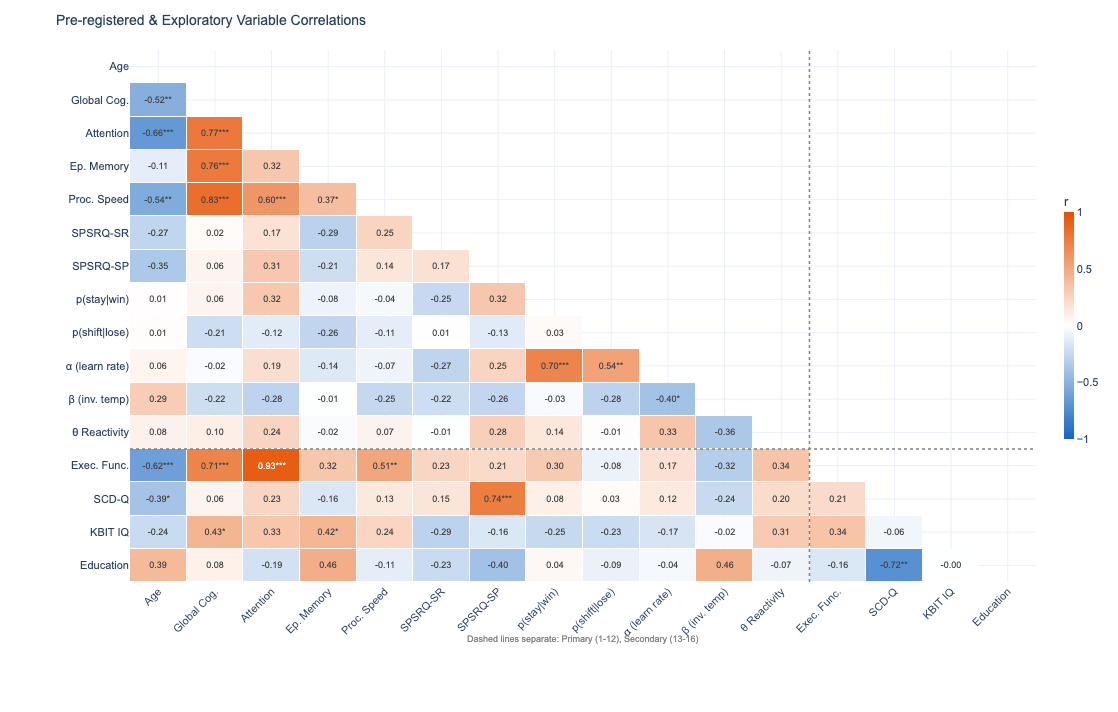

In [45]:
# Pairwise correlations among pre-registered variables
# (now includes theta_p95)
corr_results = run_correlation_analysis(subj_df, include_tertiary=False)

---
## 13. Summary

In [48]:
print('='*70)
print('ANALYSIS SUMMARY')
print('='*70)
print()

# Sample
print(f'Sample: N = {len(subj_df)}')
print(f'  H1-eligible (sham): {data_h1["subject_id"].nunique()}')
print(f'  H2-eligible (paired): {len(h2_eligible)}')
if 'theta_p95' in subj_df.columns:
    print(f'  With theta data: {subj_df["theta_p95"].notna().sum()}')
print()

# Blinding
if blinding_results['blinding_intact']:
    print('✓ Blinding intact')
else:
    print('⚠ Blinding concern')

# Order effects
if order_results['any_significant_order']:
    print('⚠ Significant order × condition interaction')
else:
    print('✓ No significant order effects')

# Theta reliability
if theta_results is not None and 'reliability' in theta_results:
    icc = theta_results['reliability'].get('ICC', np.nan)
    if not np.isnan(icc):
        if icc >= 0.75:
            print(f'✓ Theta reliability excellent (ICC = {icc:.2f})')
        elif icc >= 0.60:
            print(f'✓ Theta reliability good (ICC = {icc:.2f})')
        else:
            print(f'⚠ Theta reliability fair/poor (ICC = {icc:.2f})')

# Extended RL model comparison
if 'best_model' in extended_comparison.columns:
    best = extended_comparison['best_model'].value_counts().idxmax()
    pct = 100 * extended_comparison['best_model'].value_counts().max() / len(extended_comparison)
    print(f'✓ Best-fitting model: {best} ({pct:.0f}% of fits)')
print()

# H2.1 summary
print('H2.1 Paired Comparisons (tACS vs. Sham):')
for param, res in hyp_results['h2_1'].items():
    if res is not None:
        sig = '*' if res['p'] < 0.05 else ''
        print(f"  {param}: dz = {res['dz']:.3f}, p = {res['p']:.3f} {sig}")

ANALYSIS SUMMARY

Sample: N = 32
  H1-eligible (sham): 31
  H2-eligible (paired): 29
  With theta data: 28

✓ Blinding intact
✓ No significant order effects
✓ Theta reliability good (ICC = 0.69)
✓ Best-fitting model: standard_rw (90% of fits)

H2.1 Paired Comparisons (tACS vs. Sham):


NameError: name 'hyp_results' is not defined

---
## 14. Accuracy & Win Rate Analysis

Examines task performance metrics:
- **Run-level accuracy**: Performance across the 8 runs
- **Counterbalance effects**: Does order (sham-first vs active-first) matter?
- **Stimulation effects**: Does tACS affect accuracy or win rate?
- **Learning curves**: Within-run and within-contingency learning
- **Age effects**: Does accuracy decline with age?

In [50]:
# Import accuracy analysis module
from accuracy_analysis import run_accuracy_analysis

ACCURACY ANALYSIS
RUN-LEVEL ACCURACY SUMMARY

Total runs: 236
Subjects: 31

Overall accuracy: M = 0.646, SD = 0.112
Overall win rate: M = 0.572, SD = 0.080

Runs above chance (>50%): 215 / 236 (91.1%)
Runs near optimal (>=70%): 72 / 236 (30.5%)

CONDITION-LEVEL ACCURACY SUMMARY

SHAM:
  N = 31
  Accuracy: M = 0.639, SD = 0.095
  Win rate: M = 0.569, SD = 0.058

ACTIVE:
  N = 30
  Accuracy: M = 0.632, SD = 0.106
  Win rate: M = 0.562, SD = 0.065

COUNTERBALANCE EFFECTS ANALYSIS

Overall Accuracy by Counterbalance:
  A (sham first): M = 0.630, SD = 0.074, n = 13
  B (active first): M = 0.651, SD = 0.082, n = 18
  t = -0.71, p = 0.486, d = -0.26

Practice Effect (2nd half - 1st half) by Counterbalance:
  A: Δ = +0.017
  B: Δ = +0.035
  t = -0.65, p = 0.522

Sham Accuracy by Order:
  Sham first (CB=A): M = 0.650
  Sham second (CB=B): M = 0.632
  t = 0.51, p = 0.612

Active Accuracy by Order:
  Active first (CB=B): M = 0.654
  Active second (CB=A): M = 0.604
  t = 1.29, p = 0.207

STIMULATI

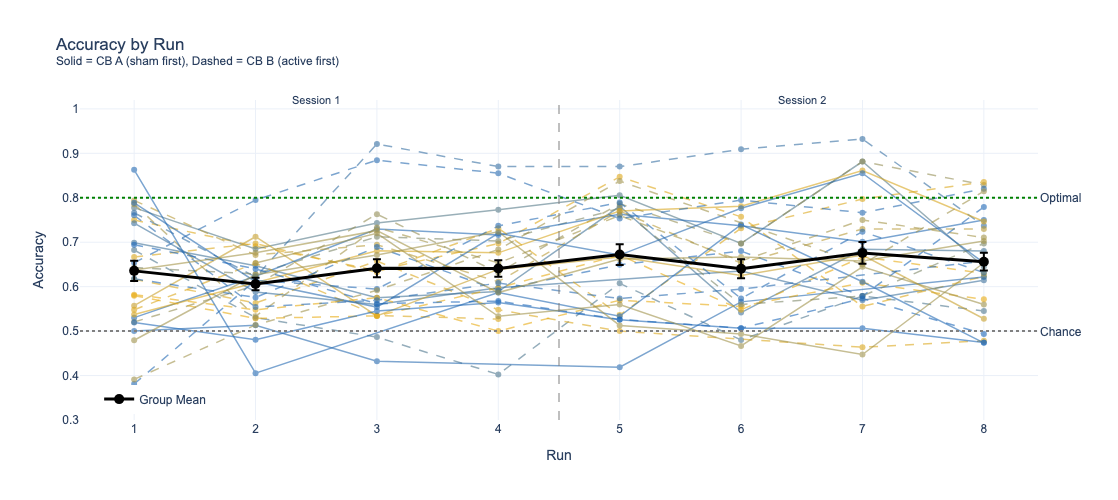

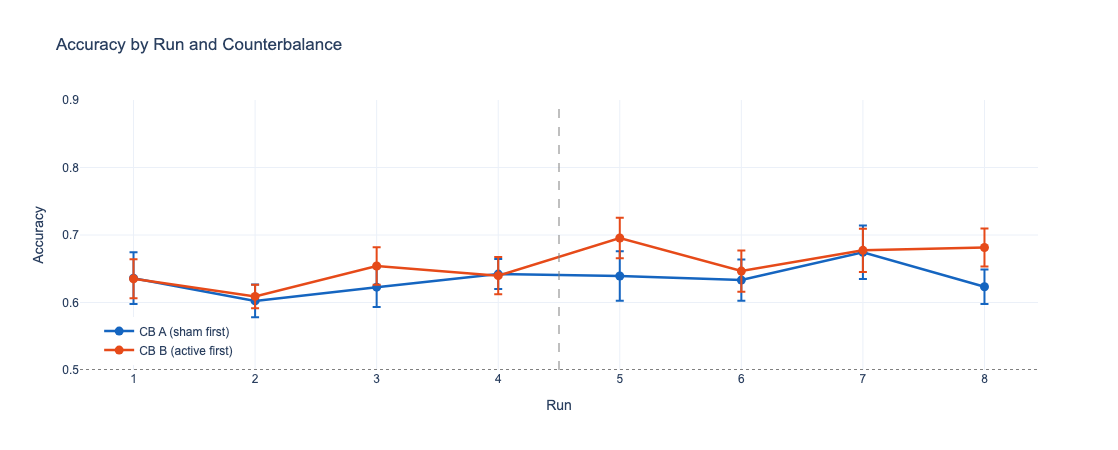

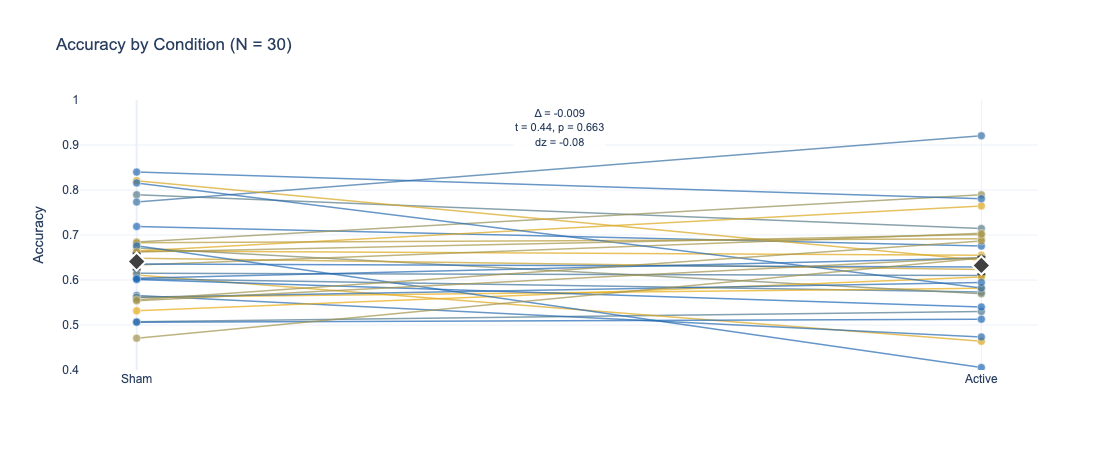

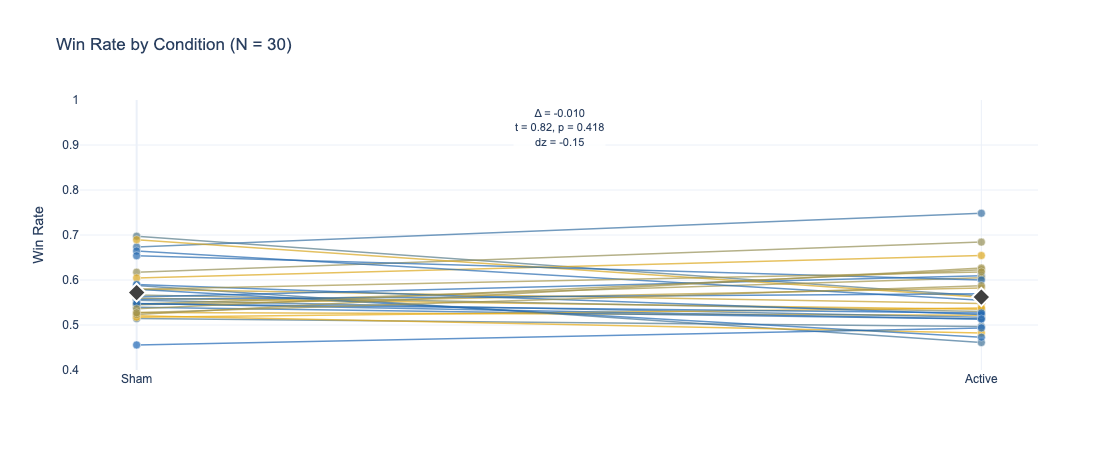

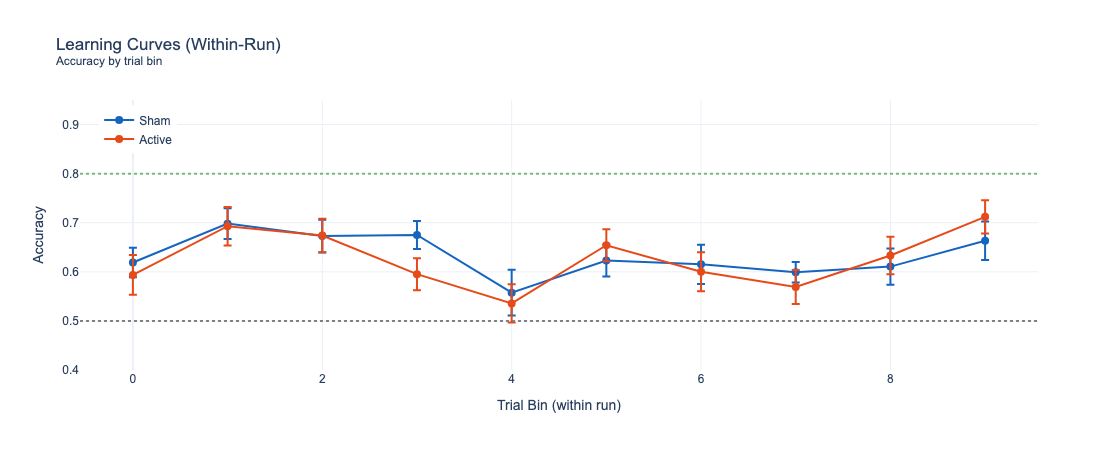

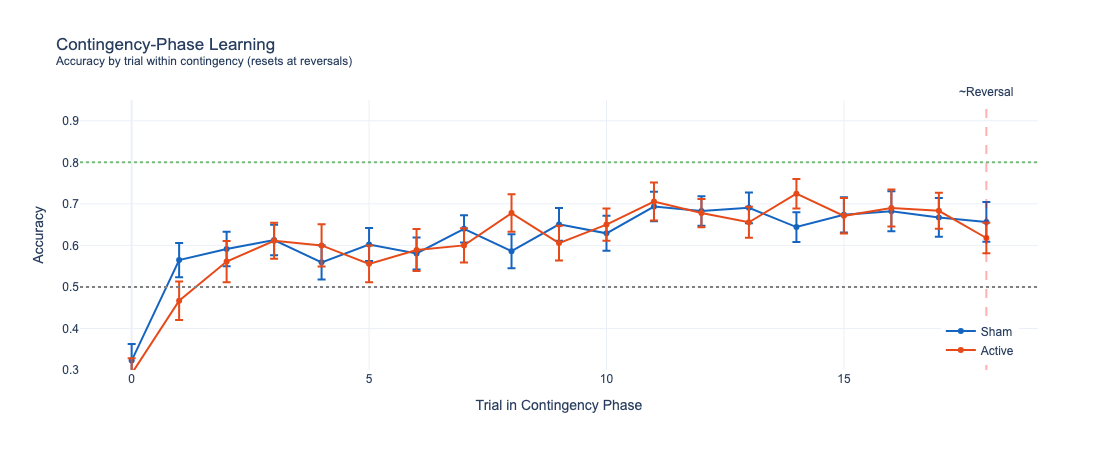

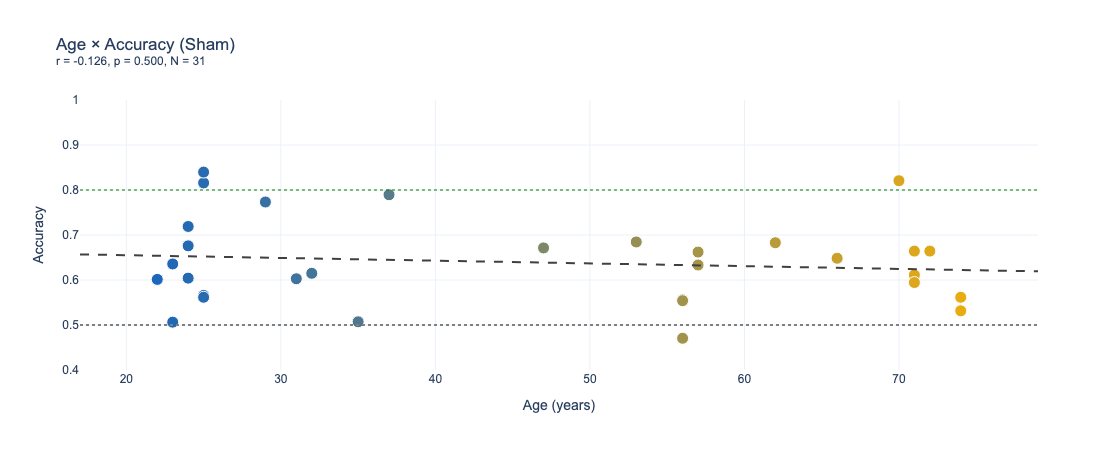

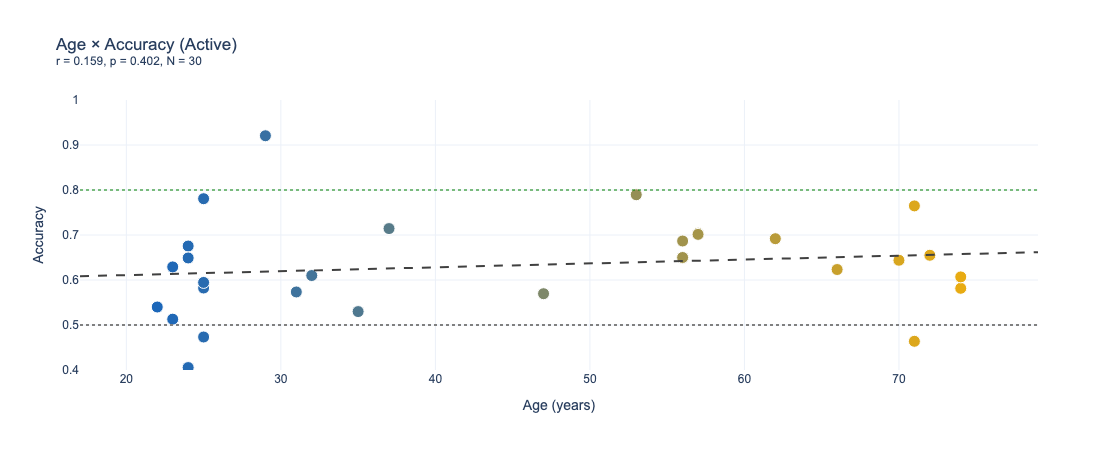

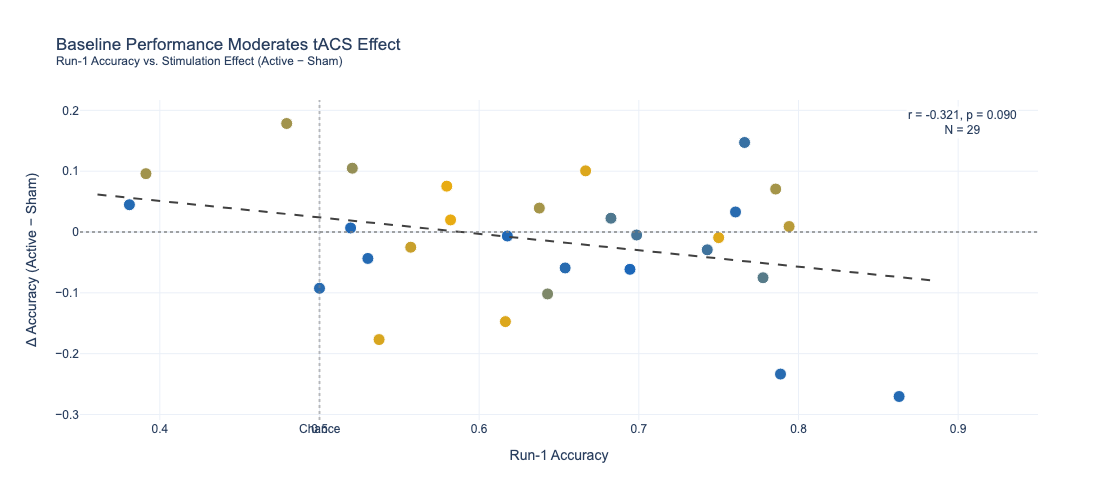

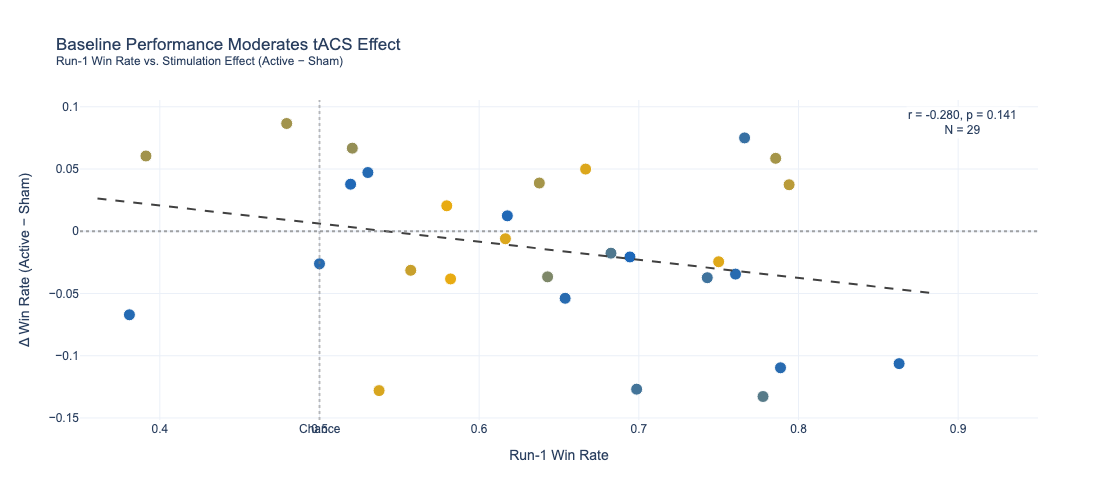


ACCURACY ANALYSIS COMPLETE


In [52]:
# Run complete accuracy analysis
acc_results = run_accuracy_analysis(
    data=data_clean,
    conditions=['sham', 'active'],
    show_plots=True,
    verbose=True
)

In [53]:
# Extract key results for reference
run_level_acc = acc_results['run_level']
cond_level_acc = acc_results['condition_level']
cb_effects = acc_results['counterbalance']
stim_effects_acc = acc_results['stimulation_effects']
age_effects_acc = acc_results['age_effects']

# Quick summary
print("\nStimulation effect on accuracy:")
if 'accuracy' in stim_effects_acc:
    r = stim_effects_acc['accuracy']
    sig = '*' if r['p'] < 0.05 else ''
    print(f"  Sham: {r['sham_mean']:.3f}, Active: {r['active_mean']:.3f}, p = {r['p']:.3f}{sig}")

print("\nStimulation effect on win rate:")
if 'win_rate' in stim_effects_acc:
    r = stim_effects_acc['win_rate']
    sig = '*' if r['p'] < 0.05 else ''
    print(f"  Sham: {r['sham_mean']:.3f}, Active: {r['active_mean']:.3f}, p = {r['p']:.3f}{sig}")


Stimulation effect on accuracy:
  Sham: 0.641, Active: 0.632, p = 0.663

Stimulation effect on win rate:
  Sham: 0.572, Active: 0.562, p = 0.418


In [54]:
# Optional: test baseline moderation on other DVs
from accuracy_analysis import test_baseline_moderates_other_dvs

baseline_other_dvs = test_baseline_moderates_other_dvs(
    run_df=acc_results['run_level'],
    wsls_h2=wsls_results.get('wsls_h2'),
    rw_df=rw_results.get('rw_mle'),
    ddm_df=ddm_results.get('ddm_subject')
)


BASELINE MODERATION OF OTHER DVs

Run-1 accuracy × Δ(active - sham) correlations:
  rw_alpha: r = 0.044, p = 0.822, n = 29
  rw_beta: r = -0.229, p = 0.232, n = 29


---
## Module Reference

| Module | Purpose |
|--------|--------|
| `config.py` | Paths, SUBJECT_INFO, colors, constants |
| `data_loading.py` | Load and preprocess behavioral data |
| `exclusions.py` | Apply behavioral and stim exclusion criteria |
| `sample_descriptives.py` | Demographics, age distribution, cap size |
| `blinding_analysis.py` | Signal detection analysis of blinding |
| `wsls.py` | Win-stay/lose-shift analysis |
| `reversal_analysis.py` | Reversal-locked accuracy curves |
| `rescorla_wagner.py` | R-W model fitting (MLE/MAP) |
| `rescorla_wagner_extended.py` | Extended R-W: asymmetric learning, stickiness, model comparison |
| `ddm.py` | Drift diffusion model fitting |
| `eeg_theta.py` | Theta reactivity from baseline EEG |
| `cognitive_merge.py` | External data integration, composites |
| `hypothesis_tests.py` | H1.1, H1.2, H2.1, H2.2, theta moderation |
| `order_effects.py` | Counterbalance and session effects |
| `correlations.py` | Correlation heatmap |
| `accuracy_analysis.py` | Run-level accuracy, learning curves, counterbalance effects |
| `plotting_utils.py` | Shared visualization utilities |